In [1]:
import pandas as pd

df = pd.read_csv("clientes_churn.csv")

df.head(20)


,cliente_id,edad,ciudad,producto,meses_activo,compras_totales,ingreso_total,soporte_tickets,medio_pago,churn
0,1,56,Rosario,tv,36,42,45387.0,5,NaN,0
1,2,69,cordoba,Telefonía,38,37,341960.0,1,Efectivo,0
2,3,46,Córdoba,internet,39,37,7642.0,5,Tarjeta,0
3,4,32,NaN,NaN,37,42,309281.0,12,Tarjeta,0
4,5,60,Buenos Aires,NaN,35,37,478048.0,5,Transferencia,0
5,6,25,rosario,Telefonía,7,35,NaN,7,NaN,0
6,7,78,Rosario,NaN,27,23,329404.0,6,Transferencia,1
7,8,38,Rosario,tv,28,6,151510.0,7,NaN,1
8,9,56,Buenos Aires,TV,22,4,315586.0,13,NaN,0
9,10,75,cordoba,Internet,14,18,370205.0,8,Transferencia,0


Ver problemas

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1020 entries, 0 to 1019
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   cliente_id       1020 non-null   int64  
 1   edad             1020 non-null   int64  
 2   ciudad           865 non-null    object 
 3   producto         851 non-null    object 
 4   meses_activo     1020 non-null   int64  
 5   compras_totales  1020 non-null   int64  
 6   ingreso_total    1000 non-null   float64
 7   soporte_tickets  1020 non-null   int64  
 8   medio_pago       778 non-null    object 
 9   churn            1020 non-null   int64  
dtypes: float64(1), int64(6), object(3)
memory usage: 79.8+ KB


In [2]:
df.isnull().sum()

,0
cliente_id,0
edad,0
ciudad,155
producto,169
meses_activo,0
compras_totales,0
ingreso_total,20
soporte_tickets,0
medio_pago,242
churn,0


In [3]:
df.duplicated().sum()

np.int64(20)

# Normalizar problemas

In [4]:
df["ciudad"] = df["ciudad"].str.strip().str.capitalize()
df["producto"] = df["producto"].str.strip().str.capitalize()
df.head()

,cliente_id,edad,ciudad,producto,meses_activo,compras_totales,ingreso_total,soporte_tickets,medio_pago,churn
0,1,56,Rosario,Tv,36,42,45387.0,5,NaN,0
1,2,69,Cordoba,Telefonía,38,37,341960.0,1,Efectivo,0
2,3,46,Córdoba,Internet,39,37,7642.0,5,Tarjeta,0
3,4,32,NaN,NaN,37,42,309281.0,12,Tarjeta,0
4,5,60,Buenos aires,NaN,35,37,478048.0,5,Transferencia,0


In [5]:
import unicodedata

def normalizar_texto(texto):
    if pd.isnull(texto):
        return texto
    texto = unicodedata.normalize('NFKD', texto)
    texto = texto.encode('ASCII', 'ignore').decode('utf-8')
    return texto

In [6]:
df["ciudad"] = df["ciudad"].apply(normalizar_texto)
df["producto"] = df["producto"].apply(normalizar_texto)
df.head()

,cliente_id,edad,ciudad,producto,meses_activo,compras_totales,ingreso_total,soporte_tickets,medio_pago,churn
0,1,56,Rosario,Tv,36,42,45387.0,5,NaN,0
1,2,69,Cordoba,Telefonia,38,37,341960.0,1,Efectivo,0
2,3,46,Cordoba,Internet,39,37,7642.0,5,Tarjeta,0
3,4,32,NaN,NaN,37,42,309281.0,12,Tarjeta,0
4,5,60,Buenos aires,NaN,35,37,478048.0,5,Transferencia,0


In [7]:
df["ciudad"].value_counts()
df["producto"].value_counts()

,count
producto,
Tv,353
Internet,345
Telefonia,153


# Reemplaza valores nulos

In [8]:
df["ciudad"] = df["ciudad"].fillna("Desconocida")
df["producto"] = df["producto"].fillna("Desconocido")
df["medio_pago"] = df["medio_pago"].fillna("Desconocido")
df.head(10)

,cliente_id,edad,ciudad,producto,meses_activo,compras_totales,ingreso_total,soporte_tickets,medio_pago,churn
0,1,56,Rosario,Tv,36,42,45387.0,5,Desconocido,0
1,2,69,Cordoba,Telefonia,38,37,341960.0,1,Efectivo,0
2,3,46,Cordoba,Internet,39,37,7642.0,5,Tarjeta,0
3,4,32,Desconocida,Desconocido,37,42,309281.0,12,Tarjeta,0
4,5,60,Buenos aires,Desconocido,35,37,478048.0,5,Transferencia,0
5,6,25,Rosario,Telefonia,7,35,NaN,7,Desconocido,0
6,7,78,Rosario,Desconocido,27,23,329404.0,6,Transferencia,1
7,8,38,Rosario,Tv,28,6,151510.0,7,Desconocido,1
8,9,56,Buenos aires,Tv,22,4,315586.0,13,Desconocido,0
9,10,75,Cordoba,Internet,14,18,370205.0,8,Transferencia,0


# Limpia edades invalidas

In [9]:
df = df[(df["edad"] >= 18) & (df["edad"] <= 90)]


# Limpiar ingresos nulos

In [10]:
df["ingreso_total"] = df["ingreso_total"].fillna(df["ingreso_total"].median())
df.head(20)

,cliente_id,edad,ciudad,producto,meses_activo,compras_totales,ingreso_total,soporte_tickets,medio_pago,churn
0,1,56,Rosario,Tv,36,42,45387.0,5,Desconocido,0
1,2,69,Cordoba,Telefonia,38,37,341960.0,1,Efectivo,0
2,3,46,Cordoba,Internet,39,37,7642.0,5,Tarjeta,0
3,4,32,Desconocida,Desconocido,37,42,309281.0,12,Tarjeta,0
4,5,60,Buenos aires,Desconocido,35,37,478048.0,5,Transferencia,0
5,6,25,Rosario,Telefonia,7,35,275628.0,7,Desconocido,0
6,7,78,Rosario,Desconocido,27,23,329404.0,6,Transferencia,1
7,8,38,Rosario,Tv,28,6,151510.0,7,Desconocido,1
8,9,56,Buenos aires,Tv,22,4,315586.0,13,Desconocido,0
9,10,75,Cordoba,Internet,14,18,370205.0,8,Transferencia,0


# Eliminar Duplicados

In [11]:
df = df.drop_duplicates()
df.head()

,cliente_id,edad,ciudad,producto,meses_activo,compras_totales,ingreso_total,soporte_tickets,medio_pago,churn
0,1,56,Rosario,Tv,36,42,45387.0,5,Desconocido,0
1,2,69,Cordoba,Telefonia,38,37,341960.0,1,Efectivo,0
2,3,46,Cordoba,Internet,39,37,7642.0,5,Tarjeta,0
3,4,32,Desconocida,Desconocido,37,42,309281.0,12,Tarjeta,0
4,5,60,Buenos aires,Desconocido,35,37,478048.0,5,Transferencia,0


In [12]:
df.describe()

,cliente_id,edad,meses_activo,compras_totales,ingreso_total,soporte_tickets,churn
count,980.000000,980.000000,980.000000,980.00000,980.000000,980.000000,980.000000
mean,498.369388,49.800000,24.340816,25.07449,265874.300000,7.214286,0.303061
std,288.501957,18.129564,13.470665,14.03256,142554.699148,4.339170,0.459816
min,1.000000,18.000000,1.000000,1.00000,5192.000000,0.000000,0.000000
25%,249.750000,35.000000,13.000000,13.00000,145455.500000,3.000000,0.000000
50%,496.500000,50.000000,24.000000,25.00000,275628.000000,7.000000,0.000000
75%,748.250000,66.000000,36.000000,37.00000,390340.500000,11.000000,1.000000
max,1000.000000,79.000000,47.000000,49.00000,498992.000000,14.000000,1.000000


In [13]:
df.to_csv("clientes_churn_limpio.csv", index=False)


# Cargar dataset Limpio

In [14]:
import pandas as pd

df = pd.read_csv("clientes_churn_limpio.csv")
df.head()


,cliente_id,edad,ciudad,producto,meses_activo,compras_totales,ingreso_total,soporte_tickets,medio_pago,churn
0,1,56,Rosario,Tv,36,42,45387.0,5,Desconocido,0
1,2,69,Cordoba,Telefonia,38,37,341960.0,1,Efectivo,0
2,3,46,Cordoba,Internet,39,37,7642.0,5,Tarjeta,0
3,4,32,Desconocida,Desconocido,37,42,309281.0,12,Tarjeta,0
4,5,60,Buenos aires,Desconocido,35,37,478048.0,5,Transferencia,0


# Tasa de churn total
La tasa general de abandono de clientes (churn) es del 30.3%, lo que indica que aproximadamente 3 de cada 10 clientes dejaron el servicio durante el período analizado.
Este valor es elevado para un negocio de servicios y sugiere la necesidad de investigar los factores que influyen en la pérdida de clientes.

In [15]:
total_clientes = len(df)
clientes_churn = df["churn"].sum()

tasa_churn = clientes_churn / total_clientes * 100

tasa_churn

np.float64(30.306122448979593)

# Promedio de abandono por ciudad
Se observa que Buenos Aires presenta la mayor tasa de churn (32.6%), mientras que Mendoza tiene la menor (29.0%).
Esto puede indicar diferencias en la calidad del servicio, competencia local o perfil de clientes por región.
Se recomienda investigar causas específicas en Buenos Aires para reducir el abandono.

In [16]:
churn_ciudad = df.groupby("ciudad")["churn"].mean().sort_values(ascending=False)
churn_ciudad


,churn
ciudad,
Buenos aires,0.326389
Rosario,0.302405
Cordoba,0.300000
Desconocida,0.297297
Mendoza,0.290598


# Producto con mas abandono
El producto con mayor tasa de abandono es TV (32.0%), seguido por Internet (31.4%).
Esto sugiere posibles problemas de satisfacción o competencia en estos servicios.
El grupo "Desconocido" presenta menor churn, lo que puede deberse a menor volumen o datos incompletos.

In [17]:
churn_producto = df.groupby("producto")["churn"].mean().sort_values(ascending=False)
churn_producto

,churn
producto,
Tv,0.320359
Internet,0.314371
Telefonia,0.308725
Desconocido,0.239264


# Churn por meses activos
Contrario a lo esperado, los clientes con mayor antigüedad (24+ meses) presentan la mayor tasa de churn.
Esto podría indicar desgaste del servicio o falta de programas de fidelización para clientes antiguos.
Se recomienda implementar estrategias de retención para clientes con más tiempo en la empresa.

## Primero creamos grupos

In [18]:
df["segmento_antiguedad"] = pd.cut(
    df["meses_activo"],
    bins=[0,6,12,24,48],
    labels=["0-6 meses","6-12 meses","12-24 meses","24+ meses"]
)
df.head()

,cliente_id,edad,ciudad,producto,meses_activo,compras_totales,ingreso_total,soporte_tickets,medio_pago,churn,segmento_antiguedad
0,1,56,Rosario,Tv,36,42,45387.0,5,Desconocido,0,24+ meses
1,2,69,Cordoba,Telefonia,38,37,341960.0,1,Efectivo,0,24+ meses
2,3,46,Cordoba,Internet,39,37,7642.0,5,Tarjeta,0,24+ meses
3,4,32,Desconocida,Desconocido,37,42,309281.0,12,Tarjeta,0,24+ meses
4,5,60,Buenos aires,Desconocido,35,37,478048.0,5,Transferencia,0,24+ meses


## Ahora churn por segmento

In [19]:
churn_antiguedad = df.groupby("segmento_antiguedad")["churn"].mean().sort_values(ascending=False)
churn_antiguedad


/tmp/ipython-input-1478819876.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_antiguedad = df.groupby("segmento_antiguedad")["churn"].mean().sort_values(ascending=False)


,churn
segmento_antiguedad,
24+ meses,0.317992
12-24 meses,0.300380
6-12 meses,0.284483
0-6 meses,0.268293


# Churn por edad
Contrario a lo esperado, los clientes con mayor antigüedad (24+ meses) presentan la mayor tasa de churn.
Esto podría indicar desgaste del servicio o falta de programas de fidelización para clientes antiguos.
Se recomienda implementar estrategias de retención para clientes con más tiempo en la empresa.

In [20]:
df["grupo_edad"] = pd.cut(
    df["edad"],
    bins=[18,30,45,60,90],
    labels=["18-30","30-45","45-60","60+"]
)

churn_edad = df.groupby("grupo_edad")["churn"].mean().sort_values(ascending=False)
churn_edad

/tmp/ipython-input-2200413301.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_edad = df.groupby("grupo_edad")["churn"].mean().sort_values(ascending=False)


,churn
grupo_edad,
60+,0.313070
18-30,0.300000
30-45,0.296943
45-60,0.290598


# Relacion con soporte

## Los que llaman mucho a soporte se van mas?
Se observa una fuerte relación entre la cantidad de tickets de soporte y la tasa de churn.
Los clientes que realizaron 6 a 9 reclamos presentan tasas de abandono superiores al 40%.
Esto sugiere que una mala experiencia con el soporte técnico es un factor crítico en la pérdida de clientes.

In [21]:
churn_soporte = df.groupby("soporte_tickets")["churn"].mean().sort_values(ascending=False)
churn_soporte.head(10)

,churn
soporte_tickets,
8,0.413793
6,0.403226
9,0.351351
0,0.344262
2,0.315789
12,0.309859
7,0.303030
11,0.301587
13,0.285714


<Axes: title={'center': 'Churn por ciudad'}, xlabel='ciudad'>

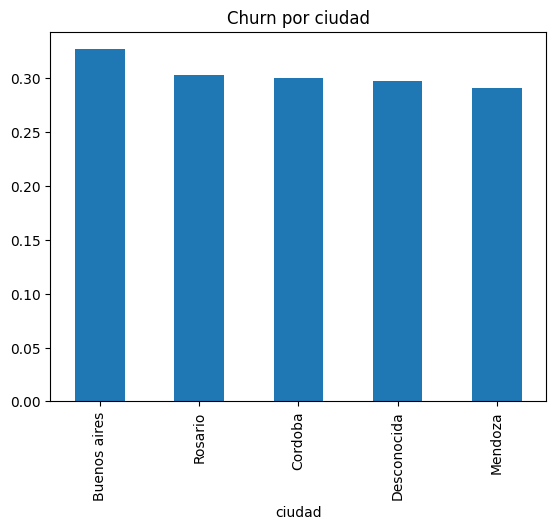

In [ ]:
churn_ciudad.plot(kind="bar", title="Churn por ciudad")


<Axes: title={'center': 'Churn por producto'}, xlabel='producto'>

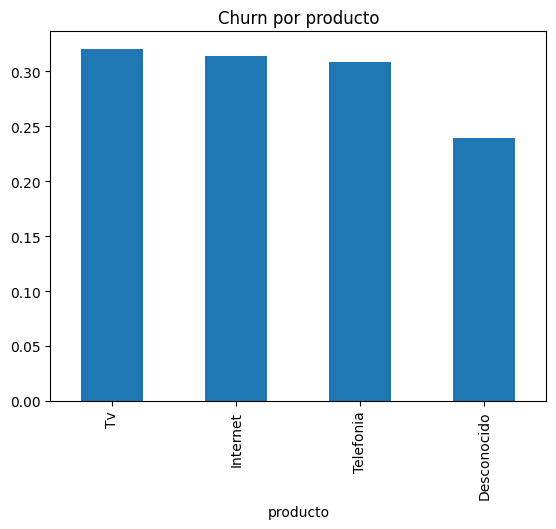

In [ ]:
churn_producto.plot(kind="bar", title="Churn por producto")


<Axes: title={'center': 'Churn por antigüedad'}, xlabel='segmento_antiguedad'>

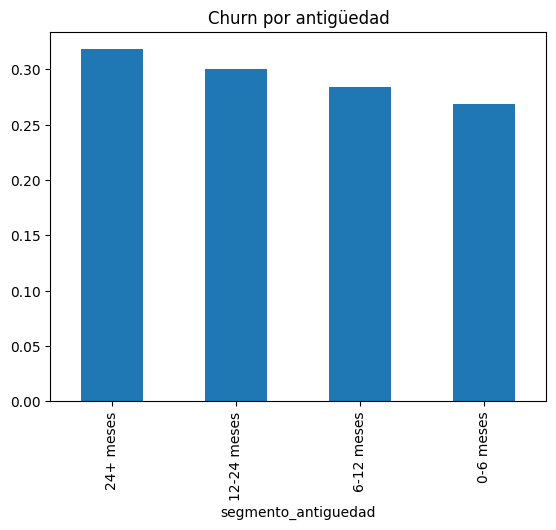

In [ ]:
churn_antiguedad.plot(kind="bar", title="Churn por antigüedad")


In [22]:
df.to_csv("clientes_churn_kpis.csv", index=False)


# Conclusion general
El análisis muestra que el churn está influenciado por múltiples factores, entre ellos la ciudad, el producto contratado, la antigüedad del cliente y la cantidad de interacciones con soporte técnico.
Los principales grupos de riesgo identificados son:

Clientes con muchos tickets de soporte (entre 6 y 9 principalmente)

Usuarios del producto TV e Internet

Clientes con más de 24 meses de antigüedad

Clientes en Buenos Aires, Rosario y Córdoba

Clientes de más de 60 años o entre el rango de 18 y 30

Estos resultados permiten orientar estrategias de retención específicas y constituyen la base para el desarrollo de un modelo predictivo de churn.

# Cargar dataset para prediccion

In [23]:
import pandas as pd

df = pd.read_csv("clientes_churn_kpis.csv")
df.head(20)
#df.isna().sum()

,cliente_id,edad,ciudad,producto,meses_activo,compras_totales,ingreso_total,soporte_tickets,medio_pago,churn,segmento_antiguedad,grupo_edad
0,1,56,Rosario,Tv,36,42,45387.0,5,Desconocido,0,24+ meses,45-60
1,2,69,Cordoba,Telefonia,38,37,341960.0,1,Efectivo,0,24+ meses,60+
2,3,46,Cordoba,Internet,39,37,7642.0,5,Tarjeta,0,24+ meses,45-60
3,4,32,Desconocida,Desconocido,37,42,309281.0,12,Tarjeta,0,24+ meses,30-45
4,5,60,Buenos aires,Desconocido,35,37,478048.0,5,Transferencia,0,24+ meses,45-60
5,6,25,Rosario,Telefonia,7,35,275628.0,7,Desconocido,0,6-12 meses,18-30
6,7,78,Rosario,Desconocido,27,23,329404.0,6,Transferencia,1,24+ meses,60+
7,8,38,Rosario,Tv,28,6,151510.0,7,Desconocido,1,24+ meses,30-45
8,9,56,Buenos aires,Tv,22,4,315586.0,13,Desconocido,0,12-24 meses,45-60
9,10,75,Cordoba,Internet,14,18,370205.0,8,Transferencia,0,12-24 meses,60+


# Preparar variables

In [24]:
# DEBE AGREGAR:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score


In [25]:
# 1. Preparar variables
# 1. Separar columnas numéricas y categóricas
num_cols = ['meses_activo', 'soporte_tickets', 'edad', 'ingreso_total']
cat_cols = ['ciudad', 'producto', 'medio_pago']

# 2. Aplicar one-hot encoding a las categóricas
X_cat = pd.get_dummies(df[cat_cols], drop_first=True)  # drop_first evita multicolinealidad

# 3. Juntar con las numéricas
X = pd.concat([df[num_cols], X_cat], axis=1)
#X = df[['meses_activo', 'soporte_tickets', 'edad', 'ingreso_total','ciudad','producto','medio_pago']]
y = df['churn']

# Entrenar Modelo

In [26]:
# 2. Entrenar
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.model_selection import GridSearchCV

# 2. Entrenar con búsqueda de hiperparámetros
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4)

# SMOTE
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Distribución original:", y_train.value_counts().values)
print("Distribución después de SMOTE:", pd.Series(y_train_res).value_counts().values)

# Definir el modelo base
modelo = RandomForestClassifier(random_state=42, class_weight='balanced')

# Parámetros a probar
param_grid = {
    'n_estimators': [300],
    'max_depth': [10, ],
    'min_samples_split': [2, ],
    'min_samples_leaf': [1],
    'max_features': ['sqrt']
}

# Búsqueda en malla con validación cruzada
grid = GridSearchCV(modelo, param_grid, cv=3, scoring='recall', n_jobs=-1)
grid.fit(X_train_res, y_train_res)

# Mejor modelo
mejor_modelo = grid.best_estimator_
print("Mejores parámetros:", grid.best_params_)



Distribución original: [404 184]
Distribución después de SMOTE: [404 404]
Mejores parámetros: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}


# Exportar modelo

In [28]:
import joblib

# GUARDAR EL QUE ESTÁ ENTRENADO
joblib.dump(mejor_modelo, 'modelo_churn.pkl')

joblib.dump(X.columns.tolist(), 'model_columns.pkl')

print("Modelo entrenado guardado correctamente.")

¡Ahora sí! Modelo entrenado guardado correctamente.


# Evaluar

In [ ]:
# 3. Evaluar
y_pred = mejor_modelo.predict(X_test)
print(classification_report(y_test, y_pred))
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred)}")

              precision    recall  f1-score   support

           0       0.67      0.86      0.75       261
           1       0.36      0.15      0.21       131

    accuracy                           0.62       392
   macro avg       0.51      0.51      0.48       392
weighted avg       0.57      0.62      0.57       392

ROC-AUC: 0.5073703606212161


# Feature importance

In [ ]:
# 4. Feature importance
importances = pd.DataFrame({
    'feature': X.columns,
    'importance': mejor_modelo.feature_importances_
}).sort_values('importance', ascending=False)
importances

,feature,importance
3,ingreso_total,0.178429
2,edad,0.161064
0,meses_activo,0.155475
1,soporte_tickets,0.116602
8,producto_Internet,0.058640
10,producto_Tv,0.055615
9,producto_Telefonia,0.045154
7,ciudad_Rosario,0.037288
6,ciudad_Mendoza,0.035086
13,medio_pago_Transferencia,0.033475


# Impacto Económico

In [ ]:
# Impacto económico
clientes_riesgo = df[df['soporte_tickets'] >= 6].shape[0]
tasa_churn_riesgo = 0.45
valor_cliente = df['ingreso_total'].mean() * 12  # LTV anual

perdida_potencial = clientes_riesgo * tasa_churn_riesgo * valor_cliente

print(f"Pérdida potencial anual: ${perdida_potencial:,.2f}")
print(f"Clientes en riesgo por cantidad de tickets: {clientes_riesgo}")

Pérdida potencial anual: $861,432,732.00
Clientes en riesgo por cantidad de tickets: 600


# Predecir para los clientes

In [ ]:
# Predecir para todos los clientes
df['prob_churn'] = mejor_modelo.predict_proba(X)[:, 1]
df['riesgo'] = pd.cut(
    df['prob_churn'],
    bins=[0, 0.3, 0.6, 1.0],
    labels=['Bajo', 'Medio', 'Alto']
)

# Top clientes en riesgo
top_riesgo = df.nlargest(170, 'prob_churn')[
    ['edad', 'meses_activo', 'soporte_tickets', 'prob_churn', 'riesgo']
]
print(top_riesgo)

     edad  meses_activo  soporte_tickets  prob_churn riesgo
733    41            32                3    0.875276   Alto
796    74            13                4    0.874721   Alto
42     33            40                3    0.858292   Alto
946    34            29                8    0.847478   Alto
148    59            40                7    0.846596   Alto
..    ...           ...              ...         ...    ...
251    68            20                2    0.549811  Medio
212    68            39               11    0.547072  Medio
511    72            41                6    0.545874  Medio
903    36            37                1    0.544806  Medio
767    66            24                8    0.542369  Medio

[170 rows x 5 columns]


In [ ]:
# Conteo absoluto de clientes por categoría de riesgo
print(df['riesgo'].value_counts())

# Porcentaje por categoría (normalizado)
print(df['riesgo'].value_counts(normalize=True) * 100)

riesgo
Medio    436
Bajo     428
Alto     116
Name: count, dtype: int64
riesgo
Medio    44.489796
Bajo     43.673469
Alto     11.836735
Name: proportion, dtype: float64


Si bien hay 600 clientes con alto volumen de reclamos (riesgo potencial), el modelo predictivo identifica a 116 clientes críticos donde la combinación de factores (edad, antigüedad y reclamos) eleva la probabilidad de abandono por encima del 60%. Estos 116 son la prioridad inmediata para acciones de retención

In [ ]:
# 2. Exportamos el df completo
df.to_csv("analisis_riesgo_clientes.csv", index=False)

In [ ]:
# Impacto económico probabilistico
clientes_riesgo = df[df['riesgo'] == "Alto"].shape[0]
tasa_churn_riesgo = 0.45
valor_cliente = df['ingreso_total'].mean() * 12  # LTV anual

perdida_potencial = clientes_riesgo * tasa_churn_riesgo * valor_cliente

print(f"Pérdida potencial anual: ${perdida_potencial:,.2f}")
print(f"Clientes en riesgo por probabilidad: {clientes_riesgo}")

Pérdida potencial anual: $166,543,661.52
Clientes en riesgo por probabilidad: 116


# Ingreso total en riesgo (Suma de los ingresos de clientes 'Alto')

In [ ]:
ingreso_en_riesgo = df[df['riesgo'] == 'Alto']['ingreso_total'].sum()
print(f"Ingreso mensual en riesgo crítico: ${ingreso_en_riesgo:,.2f}")

Ingreso mensual en riesgo crítico: $29,531,820.00
